This notebook loads AQUM model outputs, extracts key air-quality and meteorological features (both gridded fields and values at AURN sites) as hourly data. 

It then saves the processed datasets to NetCDF files for downstream interpolation, rasterisation, and machine-learning workflows.

# Import things

In [4]:
import warnings

import numpy as np

from matplotlib import pyplot as plt

from scipy.interpolate import griddata

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from pykrige.rk import Krige
from sklearn.model_selection import GridSearchCV

import iris
import iris.coord_categorisation as coord_cat
from iris.analysis.cartography import rotate_pole, unrotate_pole

iris.FUTURE.save_split_attrs = True
# iris.FUTURE.datum_support = False
# turn off futurewarning from iris
warnings.filterwarnings("ignore", category=FutureWarning)
# turn off netcdf unknown variable warning from iris
warnings.filterwarnings("ignore", category=UserWarning, message=".*NetCDF variable.*")

/data/users/florent.malavelle/.conda/envs/MLFoundationsEnv/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


# User functions

In [5]:
def calc_daily_mean(file_stem=None,
                    output_path=None,
                    cubelist=None):
    """Calculate daily mean from the input cubelist and save the output as a netcdf file.
    Args:
        file_stem (str): the stem of the output file name, e.g. 'model_feature'
        output_path (str): the path to save the output file, e.g. '/path/to/output'
        cubelist (iris.cube.CubeList): the input cubelist to be processed, e.g. the output of extract_model_feature() function
        Returns:
            iris.cube.CubeList: the cubelist after calculating daily means
    """


    if cubelist is None:
        raise ValueError("cubelist to be processed is None")
    
    cubelist_by_day_out = iris.cube.CubeList()

    for cube in cubelist:
        
        # if cube name has 'daily_air_quality' in it, then it is already daily averaged, so skip it
        if 'DAQI' in cube.attributes['short_name']:
            print(f'{cube.attributes["short_name"]} is already daily averaged, skipping it')
            continue

        print(f'Processing {cube.attributes["short_name"]}')
        #print(cube)

        if not cube.coord('time').has_bounds():
            print(f'adding bounds to time coord')
            cube.coord('time').guess_bounds()
    
        #cube.remove_coord('forecast_period')
        #cube.remove_coord('forecast_day')
        #cube = cube.collapsed('time', iris.analysis.MEAN)
        #print(cube)
        #print(cube.data)
        #cubelist_out.append(cube)
    
        if not cube.coords('year'):
            coord_cat.add_year(cube, 'time', name='year')
        if not cube.coords('month'):
            coord_cat.add_month(cube, 'time', name='month')
        if not cube.coords('day_of_year'):
            coord_cat.add_day_of_year(cube, 'time', name='day_of_year')

        cd = cube.copy().aggregated_by(['day_of_year'], iris.analysis.MEAN)
        cubelist_by_day_out.append(cd)
    
    # print(f"\nResults after temporal averaging:")
    # print(cubelist_by_day_out)

    file_day_out = output_path + '/' + file_stem + "_daily_mean.nc"
    iris.save(cubelist_by_day_out, file_day_out)

    return cubelist_by_day_out


In [6]:
def guess_coord_names(cube, axes):
    """
    Guess the coordinate names for the specified axes in the input cube.
    Args:
        cube (iris.cube.Cube): The input cube to be processed.
        axes (list of str): The list of axes to guess coordinate names for.
    Returns:
        list of str: The guessed coordinate names for the specified axes.
    """

    coord_names = [None] * len(axes)
    for coord in cube.coords():
        axis = iris.util.guess_coord_axis(coord)
        for i, ax in enumerate(axes):
            if axis == ax:
                if coord_names[i] is None:
                    coord_names[i] = coord.name()

    return coord_names

In [7]:
def extract_cube_area(cube=None, 
                      MINLON=None,
                      MAXLON=None,
                      MINLAT=None,
                      MAXLAT=None):
    """Extract a sub-area of the input cube based on the specified longitude and latitude bounds.
    Args:
    cube (iris.cube.Cube): the input cube to be processed, e.g. the output of extract_model_feature() function
    MINLON (float): the minimum longitude bound, e.g. -11.5
    MAXLON (float): the maximum longitude bound, e.g. 5
    MINLAT (float): the minimum latitude bound, e.g. 48.5
    MAXLAT (float): the maximum latitude bound, e.g. 61
    Returns:
    iris.cube.Cube: the extracted cube over the specified area
    """

    if MINLON is None:
        MINLON = -11.5
    if MAXLON is None:
        MAXLON = 5
    if MINLAT is None:
        MINLAT = 48.5
    if MAXLAT is None:
        MAXLAT = 61

    if cube is None:
        raise ValueError(f"No cube has been specified")
    
    if not isinstance(cube, iris.cube.Cube):
        raise ValueError(f"{cube} is not an Iris cube")

    ycoord, xcoord = None, None
    ycoord, xcoord  = guess_coord_names(cube, ["Y", "X"])
    #print(cube.coord(xcoord))
    #print(cube.coord(ycoord))

    if None in [xcoord, ycoord]:
        raise ValueError(f"Can not unroate coordinates for {cube}")

    print(f"\n(xcoord,ycoord): ({xcoord},{ycoord})")

    # define reg latlon coordinate system and pair of locations
    # to be derived in the cube coordinate space.
    lat_lon_coord_system = iris.coord_systems.GeogCS(
        semi_major_axis=iris.fileformats.pp.EARTH_RADIUS
    )
    lons = np.array([MINLON, MAXLON], dtype=float)
    lats = np.array([MINLAT, MAXLAT], dtype=float)

    # Calculate pair location in cube coordinates
    if xcoord != "longitude" and ycoord != "latitude":

        if xcoord == "grid_longitude" and ycoord == "grid_latitude":
            # rotated coord ...
            pole_lon = cube.coord(xcoord).coord_system.grid_north_pole_longitude
            pole_lat = cube.coord(ycoord).coord_system.grid_north_pole_latitude
            
            # Perform rotation
            rot_lons, rot_lats = rotate_pole(lons, lats, pole_lon, pole_lat)
            rot_lons = rot_lons + 360
            
            print(f"Reg Lat {lats} converted to " + \
                  f"rotated lat coord: {rot_lats}")
            print(f"Reg Lon {lons} converted to " + \
                  f"rotated lon coord: {rot_lons}")

            lat_constraint = iris.Constraint(
                grid_latitude=lambda cell: rot_lats[0] < cell < rot_lats[1]
                )
            lon_constraint = iris.Constraint(
                grid_longitude=lambda cell: rot_lons[0] < cell < rot_lons[1]
                )

            cube = cube.extract(lon_constraint & lat_constraint)

        elif (xcoord == "projection_x_coordinate" and 
              ycoord == "projection_y_coordinate"):
            # Other coordinate system (note this may work for x/ycoords other than
            # those considered here
            ll_crs = lat_lon_coord_system.as_cartopy_crs()
            cube_crs = cube.coord(xcoord).coord_system.as_cartopy_crs()

            # Convert to lat/lon points
            cube_lonlats = cube_crs.transform_points(ll_crs, lons, lats)
            cube_lons = cube_lonlats[:, 0]
            cube_lats = cube_lonlats[:, 1]

            print(f"\nReg Lat {lats} converted to " + \
                  f"projection_y_coordinate: {cube_lats}")
            print(f"Reg Lon {lons} converted to " + \
                  f"projection_x_coordinate: {cube_lons}")
            
            lat_constraint = iris.Constraint(
                projection_y_coordinate=lambda cell: cube_lats[0] < cell < cube_lats[1]
                )
            lon_constraint = iris.Constraint(
                projection_x_coordinate=lambda cell: cube_lons[0] < cell < cube_lons[1]
                )

            cube = cube.extract(lon_constraint & lat_constraint)

    else:
        lat_constraint = iris.Constraint(
            latitude=lambda cell: lats[0] < cell < lats[1]
        )
        lon_constraint = iris.Constraint(
            longitude=lambda cell: lons[0] < cell < lons[1]
        )
        cube = cube.extract(lon_constraint & lat_constraint)


    return(cube)


# Open AQUM data 

## Loading hourly data from the UM

In [18]:
model_datadir = 'processed_data/'

# open model 2D fields
gridded_cube_list_files = 'AQUM-C_gridded_cube_list.nc'

#open model data extracted at AURN sites
site_cube_list_files = 'AQUM-C_sites_cube_list.nc'

# open model 2D fields
gridded_cube_list = iris.load(model_datadir + '/' + gridded_cube_list_files)  

#open model data extracted at AURN sites
site_cube_list = iris.load(model_datadir + '/' + site_cube_list_files)

# print the cube lists
print(f'\nGridded cube list:')
print(f"{gridded_cube_list}")

print(f'\nSite cube list:')
print(f"{site_cube_list}")   


Gridded cube list:
0: daily_air_quality_index_of_nitrogen_monoxide / (1) (time: 93; grid_latitude: 182; grid_longitude: 146)
1: daily_air_quality_index_of_nitrogen_dioxide / (1) (time: 93; grid_latitude: 182; grid_longitude: 146)
2: daily_air_quality_index / (1)       (time: 93; grid_latitude: 182; grid_longitude: 146)
3: daily_air_quality_index_of_sulfur_dioxide / (1) (time: 93; grid_latitude: 182; grid_longitude: 146)
4: daily_air_quality_index_of_ozone / (1) (time: 93; grid_latitude: 182; grid_longitude: 146)
5: air_pressure_at_sea_level / (Pa)    (time: 2209; grid_latitude: 182; grid_longitude: 146)
6: air_temperature / (K)               (time: 2209; grid_latitude: 182; grid_longitude: 146)
7: mass_concentration_of_ammonia_in_air / (ug/m3) (time: 737; grid_latitude: 182; grid_longitude: 146)
8: mass_concentration_of_nitrogen_dioxide_in_air / (ug/m3) (time: 2209; grid_latitude: 182; grid_longitude: 146)
9: mass_concentration_of_nitrogen_monoxide_in_air / (ug/m3) (time: 2209; grid_l

## Subsample the gridded data

In [10]:
for i, cube in enumerate(gridded_cube_list):
    gridded_cube_list[i] = extract_cube_area(cube)
    
print(gridded_cube_list)


(xcoord,ycoord): (grid_longitude,grid_latitude)
Reg Lat [48.5 61. ] converted to rotated lat coord: [-3.62834993  8.69067472]
Reg Lon [-11.5   5. ] converted to rotated lon coord: [354.03823288 363.67031889]

(xcoord,ycoord): (grid_longitude,grid_latitude)
Reg Lat [48.5 61. ] converted to rotated lat coord: [-3.62834993  8.69067472]
Reg Lon [-11.5   5. ] converted to rotated lon coord: [354.03823288 363.67031889]

(xcoord,ycoord): (grid_longitude,grid_latitude)
Reg Lat [48.5 61. ] converted to rotated lat coord: [-3.62834993  8.69067472]
Reg Lon [-11.5   5. ] converted to rotated lon coord: [354.03823288 363.67031889]

(xcoord,ycoord): (grid_longitude,grid_latitude)
Reg Lat [48.5 61. ] converted to rotated lat coord: [-3.62834993  8.69067472]
Reg Lon [-11.5   5. ] converted to rotated lon coord: [354.03823288 363.67031889]

(xcoord,ycoord): (grid_longitude,grid_latitude)
Reg Lat [48.5 61. ] converted to rotated lat coord: [-3.62834993  8.69067472]
Reg Lon [-11.5   5. ] converted to ro

## Filter rural background sites (not used)

In [14]:
print(f'\nsite_cube_list[0]: {site_cube_list.extract(iris.Constraint(name="air_pressure_at_sea_level"))}')
print(f'\nsite_cube_list[0].coord("site_type").points: {site_cube_list[0].coord("site_type").points}')
rural_constratint = iris.Constraint(site_type=['RURAL_BACKGROUND'])
rural_sites = site_cube_list.extract(rural_constratint)
print(f'\nRural sites cube list:')
print(f"{rural_sites}")


site_cube_list[0]: 0: air_pressure_at_sea_level / (Pa)    (site_id: 108; time: 2209)

site_cube_list[0].coord("site_type").points: ['RURAL_BACKGROUND' 'SUBURBAN_BACKGROUND' 'URBAN_BACKGROUND'
 'RURAL_BACKGROUND' 'URBAN_BACKGROUND' 'RURAL_BACKGROUND'
 'URBAN_BACKGROUND' 'URBAN_BACKGROUND' 'RURAL_BACKGROUND'
 'RURAL_BACKGROUND' 'URBAN_BACKGROUND' 'RURAL_BACKGROUND'
 'RURAL_BACKGROUND' 'RURAL_BACKGROUND' 'URBAN_BACKGROUND'
 'URBAN_BACKGROUND' 'URBAN_BACKGROUND' 'SUBURBAN_BACKGROUND'
 'RURAL_BACKGROUND' 'RURAL_BACKGROUND' 'URBAN_BACKGROUND'
 'URBAN_BACKGROUND' 'RURAL_BACKGROUND' 'RURAL_BACKGROUND'
 'RURAL_BACKGROUND' 'RURAL_BACKGROUND' 'URBAN_BACKGROUND'
 'URBAN_BACKGROUND' 'URBAN_BACKGROUND' 'URBAN_BACKGROUND'
 'RURAL_BACKGROUND' 'URBAN_BACKGROUND' 'URBAN_BACKGROUND'
 'URBAN_BACKGROUND' 'URBAN_BACKGROUND' 'URBAN_BACKGROUND'
 'URBAN_BACKGROUND' 'SUBURBAN_BACKGROUND' 'URBAN_BACKGROUND'
 'RURAL_BACKGROUND' 'URBAN_BACKGROUND' 'URBAN_BACKGROUND'
 'URBAN_BACKGROUND' 'RURAL_BACKGROUND' 'URBAN_B

## Save hourly means

In [16]:
# print(f"\nCalculating daily means for gridded cubes...")
# gridded_cube_list_daily = \
#     calc_daily_mean(file_stem=gridded_cube_list_files.replace('.nc', ''),
#                     output_path=model_datadir,
#                     cubelist=gridded_cube_list
#                     )
# print(f"\nDone calculating daily means for gridded cubes ...")
# print(f"\nGridded cube list after daily averaging:")
# print(f"{gridded_cube_list_daily}")

# print(f"\nCalculating daily means for site cubes...")
# site_cube_list_daily = \
#     calc_daily_mean(file_stem=site_cube_list_files.replace('.nc', ''),
#                     output_path=model_datadir,
#                     cubelist=site_cube_list
#                     )
# print(f"\nDone calculating daily means for site cubes ...")
# print(f"\nSite cube list after daily averaging:")
# print(f"{site_cube_list_daily}")

output_path = model_datadir

print(f"\nSaving hourly means for gridded cubes...")
file_stem = gridded_cube_list_files.replace('.nc', '')
file_hourly_out = output_path + '/' + file_stem + "_hourly_means.nc"
iris.save(gridded_cube_list, file_hourly_out)
print(f"\nDone saving hourly means for gridded cubes ...")

print(f"\nSaving hourly means for site cubes...")
file_stem = site_cube_list_files.replace('.nc', '')
file_hourly_out = output_path + '/' + file_stem + "_hourly_means.nc"
iris.save(site_cube_list, file_hourly_out)
print(f"\nDone saving hourly means for site cubes ...")



Saving hourly means for gridded cubes...

Done saving hourly means for gridded cubes ...

Saving hourly means for site cubes...

Done saving hourly means for site cubes ...


## Sanity Check - Read hourly mean files and interpolate UM values at sites onto UM grid

In [19]:
# load the hourly means from post processed files
model_datadir = 'processed_data/'
gridded_cube_list_hourly = iris.load(model_datadir + '/AQUM-C_gridded_cube_list_hourly_means.nc')
site_cube_list_hourly = iris.load(model_datadir + '/AQUM-C_sites_cube_list_hourly_means.nc')

print(f"\nGridded cube list after loading hourly means:")
print(gridded_cube_list_hourly)
print(f"\nSite cube list after loading hourly means:")
print(site_cube_list_hourly)

Ozone_constraint = iris.AttributeConstraint(short_name='O3')
ozone_gridded = gridded_cube_list_hourly.extract_cube(Ozone_constraint)
ozone_sites = site_cube_list_hourly.extract_cube(Ozone_constraint)

for i, (ozone_cube_t, site_cube) in enumerate(zip(ozone_gridded.slices_over('time'), ozone_sites.slices_over('time'))):

    # end loop after 3 iteration
    if i >= 3:
        break

    time_coord = ozone_cube_t.coord('time')
    dt = time_coord.units.num2date(time_coord.points)       # returns an array-like of datetimes
    date_str = dt[0].strftime("%Y-%m-%d %H:%M:%S")          # format as you like
    print(f'{i} - Processing cubes for date: {date_str}')

    sites_lat = []
    sites_lon = []
    sites_rotated_lat = []
    sites_rotated_lon = []
    sites_ozone = []

    # unpack the site_cube data and coords
    for site in site_cube.slices_over('site_id'):
        site_id = site.coord('site_id').points[0]
        site_lat = site.coord('latitude').points[0]
        site_lon = site.coord('longitude').points[0]
        # site_id_regen = adaq_data.generate_siteids(site_lon, site_lat)
        site_rotated_lat = site.coord('grid_latitude').points[0]
        site_rotated_lon = site.coord('grid_longitude').points[0]
        sites_ozone.append(site.data)
        sites_lat.append(site_lat)
        sites_lon.append(site_lon)
        sites_rotated_lat.append(site_rotated_lat)
        sites_rotated_lon.append(site_rotated_lon)
        # print(f"Site ID: {site_id}")
        # print(f"Site lat: {site_lat}, Site lon: {site_lon}")
        # print(f"Site rotated lat: {site_rotated_lat}, Site rotated lon: {site_rotated_lon}")

print(f"\nOriginal site latitudes: {sites_lat}")
print(f"Original site longitudes: {sites_lon}")
print(f"Sites rotated lat: {sites_rotated_lat}")
print(f"Sites rotated lon: {sites_rotated_lon}")
print(f"Sites ozone: {sites_ozone}")



Gridded cube list after loading hourly means:
0: daily_air_quality_index_of_nitrogen_monoxide / (1) (time: 93; grid_latitude: 112; grid_longitude: 88)
1: daily_air_quality_index_of_nitrogen_dioxide / (1) (time: 93; grid_latitude: 112; grid_longitude: 88)
2: daily_air_quality_index / (1)       (time: 93; grid_latitude: 112; grid_longitude: 88)
3: daily_air_quality_index_of_sulfur_dioxide / (1) (time: 93; grid_latitude: 112; grid_longitude: 88)
4: daily_air_quality_index_of_ozone / (1) (time: 93; grid_latitude: 112; grid_longitude: 88)
5: air_pressure_at_sea_level / (Pa)    (time: 2209; grid_latitude: 112; grid_longitude: 88)
6: air_temperature / (K)               (time: 2209; grid_latitude: 112; grid_longitude: 88)
7: mass_concentration_of_ammonia_in_air / (ug/m3) (time: 737; grid_latitude: 112; grid_longitude: 88)
8: mass_concentration_of_nitrogen_dioxide_in_air / (ug/m3) (time: 2209; grid_latitude: 112; grid_longitude: 88)
9: mass_concentration_of_nitrogen_monoxide_in_air / (ug/m3) (

# Interpolate sites to UM grid and Plot


Target grid shape: (112, 88), (112, 88)


/data/users/florent.malavelle/.conda/envs/MLFoundationsEnv/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging


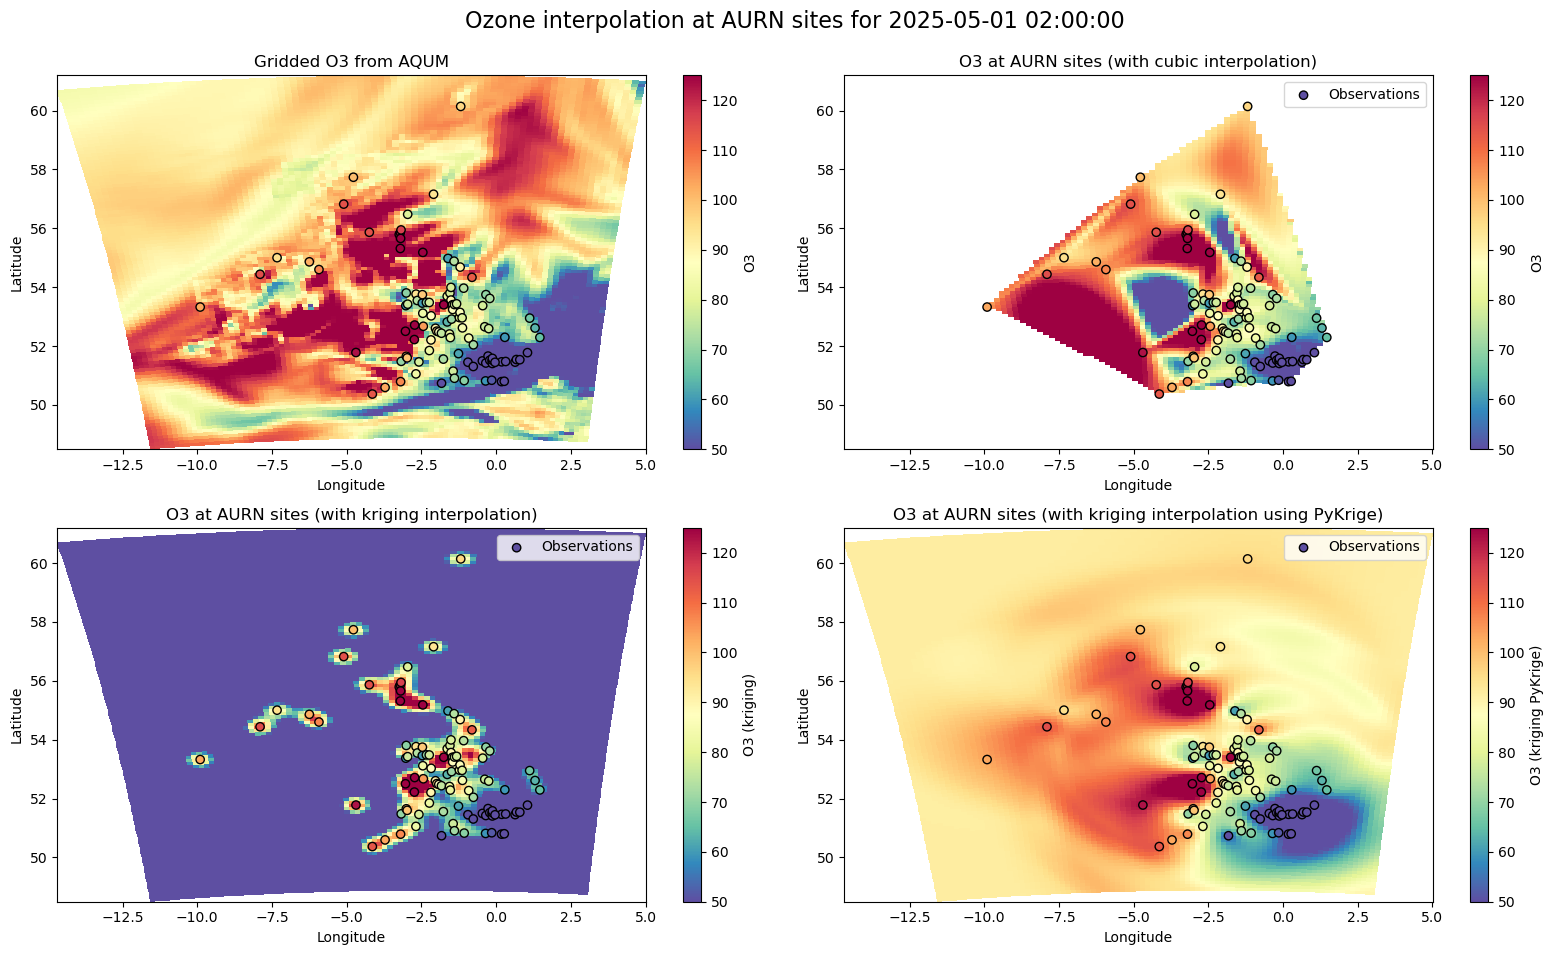

In [23]:
cube_ozone = ozone_cube_t.copy()

# Rotated pole properties
pole_lon = cube_ozone.coord('grid_longitude').coord_system.grid_north_pole_longitude
pole_lat = cube_ozone.coord('grid_latitude').coord_system.grid_north_pole_latitude

# ------------------------
# Sample scattered points
# ------------------------
lats_obs = np.array(sites_lat)
lons_obs = np.array(sites_lon)
rot_lats_obs = np.array(sites_rotated_lat)
rot_lons_obs = np.array(sites_rotated_lon)
values = np.array(sites_ozone)

# -----------------------------------
# Define the target regular lat/lon grid (use rotated grid from AQUM)
# -----------------------------------
lat_grid = cube_ozone.coord('grid_latitude').points
lon_grid = cube_ozone.coord('grid_longitude').points - 360.0
# print(f"\nTarget lat grid: {lat_grid}")
# print(f"\nTarget lon grid: {lon_grid}")
lon2d, lat2d = np.meshgrid(lon_grid, lat_grid)
print(f"\nTarget grid shape: {lat2d.shape}, {lon2d.shape}")

# print(f"\n cube_ozone.coord('grid_longitude'): {cube_ozone.coord('grid_longitude').points}")

# unrotate requires x/y arrays with identical shapes
# use the 2D rotated meshgrid (lon2d, lat2d), not separate 1D axes
lon2d_unrotated, lat2d_unrotated = unrotate_pole(lon2d, lat2d, pole_lon, pole_lat)

# -----------------------------------
# Basic Interpolation
# -----------------------------------
interpol_type = 'nearest' 
interpol_type = 'linear' 
interpol_type = 'cubic'  # 'nearest', 'linear', 'cubic'

points = np.column_stack((rot_lats_obs, rot_lons_obs))
# points = np.column_stack((lats_obs, lons_obs))

grid_points = np.column_stack((lat2d.ravel(), lon2d.ravel()))

interpolated_values = griddata(
    points, values, grid_points,
    method = interpol_type   # linear interpolation
)

interpolated_values = interpolated_values.reshape(lat2d.shape)  # back to 2D
# interpolated_values now holds your field on (lat_grid x lon_grid)

# -----------------------------------
# Kriging interpolation (optional, more complex)
# -----------------------------------
# 1. Define the kernel (e.g., Squared Exponential / RBF)
# 'kriging' range is controlled by length_scale
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))

# 2. Instantiate and fit the model
# alpha corresponds to the 'nugget' effect (noise)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=0.1)
X_train = np.column_stack((rot_lats_obs, rot_lons_obs))
Y_train = values
gp.fit(X_train, Y_train)

# 3. Predict values and uncertainty (standard deviation)
X_grid = np.column_stack((lat2d.ravel(), lon2d.ravel()))
y_pred, sigma = gp.predict(X_grid, return_std=True)
kriging_values = y_pred.reshape(lat2d.shape)  # back to 2D  


# -----------------------------------
# Kriging with PyKrige
# -----------------------------------


# Define the wrapper with your chosen method ('ordinary' or 'universal')
# and a variogram model (e.g., 'spherical', 'gaussian', 'exponential')
estimator = Krige(method='ordinary', variogram_model='spherical')

# Define parameters for a Grid Search
param_dict = {
    "method": ["ordinary", "universal"],
    "variogram_model": ["linear", "gaussian", "spherical"],
}

# Use scikit-learn's GridSearchCV to find the best parameters
grid_search = GridSearchCV(estimator, param_dict, cv=5)
X_train = np.column_stack((rot_lats_obs, rot_lons_obs))
Y_train = values
grid_search.fit(X_train, Y_train)

# Predict as you would with any sklearn model
X_test = np.column_stack((lat2d.ravel(), lon2d.ravel()))
predictions = grid_search.predict(X_test)
kriging_v2_values = predictions.reshape(lat2d.shape)  # back to 2D  

# -----------------------------------
# plotting
# -----------------------------------
fig = plt.figure(figsize=(16,10))
cmap = 'Spectral_r' 
min_o3 = 50
max_o3 = 125


# 1 - plot gridded ozone field from AQUM
ax1 = fig.add_subplot(2,2,1)
pcm2 = ax1.pcolormesh(lon2d_unrotated, lat2d_unrotated, ozone_cube_t.data, cmap=cmap, shading='auto', vmin=min_o3, vmax=max_o3)
fig.colorbar(pcm2, ax=ax1, label='O3')
ax1.set_title(f'Gridded O3 from AQUM')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')  
scatter = ax1.scatter(lons_obs, lats_obs, c=values, cmap=cmap, edgecolor='black', label='Observations', vmin=min_o3, vmax=max_o3)

# 2 - plot interpolated field
ax2 = fig.add_subplot(2,2,2)
pcm = ax2.pcolormesh(lon2d_unrotated, lat2d_unrotated, interpolated_values, cmap=cmap, shading='auto', vmin=min_o3, vmax=max_o3)
fig.colorbar(pcm, ax=ax2, label='O3')
ax2.set_title(f'O3 at AURN sites (with {interpol_type} interpolation)')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
# #overlay original points
# ax2.scatter(lons_obs, lats_obs, c='red', edgecolor='black', label='Observations')
# color original points by their values
scatter = ax2.scatter(lons_obs, lats_obs, c=values, cmap=cmap, edgecolor='black', label='Observations', vmin=min_o3, vmax=max_o3)
ax2.legend() 

# 3 - plot interpolated field with kriging
ax3 = fig.add_subplot(2,2,3)
pcm3 = ax3.pcolormesh(lon2d_unrotated, lat2d_unrotated, kriging_values, cmap=cmap, shading='auto', vmin=min_o3, vmax=max_o3)
fig.colorbar(pcm3, ax=ax3, label='O3 (kriging)')
ax3.set_title(f'O3 at AURN sites (with kriging interpolation)')
ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')
scatter = ax3.scatter(lons_obs, lats_obs, c=values, cmap=cmap, edgecolor='black', label='Observations', vmin=min_o3, vmax=max_o3)
ax3.legend()

# 4 - plot interpolated field with kriging using PyKrige
ax4 = fig.add_subplot(2,2,4)
pcm4 = ax4.pcolormesh(lon2d_unrotated, lat2d_unrotated, kriging_v2_values, cmap=cmap, shading='auto', vmin=min_o3, vmax=max_o3)
fig.colorbar(pcm4, ax=ax4, label='O3 (kriging PyKrige)')
ax4.set_title(f'O3 at AURN sites (with kriging interpolation using PyKrige)')
ax4.set_xlabel('Longitude')
ax4.set_ylabel('Latitude')
scatter = ax4.scatter(lons_obs, lats_obs, c=values, cmap=cmap, edgecolor='black', label='Observations', vmin=min_o3, vmax=max_o3)
ax4.legend()

# # UK map window (unrotated lon/lat)
# uk_lon_min, uk_lon_max = -11.0, 3.0
# uk_lat_min, uk_lat_max = 48.0, 61.5

# # Apply UK zoom to all panels
# for ax in (ax1, ax2, ax3, ax4):
#     ax.set_xlim(uk_lon_min, uk_lon_max)
#     ax.set_ylim(uk_lat_min, uk_lat_max)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# add title with date
fig.suptitle(f'Ozone interpolation at AURN sites for {date_str}', fontsize=16)

# Show plot 
plt.show()